In [ ]:
# When running locally (not Colab), make sure the working directory is the
# repository root so `csdc618_dscd604` imports and dataset paths resolve.
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")


In [1]:
import sys, os
from pathlib import Path
from google.colab import drive

# Mount Google Drive to access your files
drive.mount('/content/drive')

# TODO: Enter the root path on your PC where you have saved the unzipped
# assignment folder. This path should now be relative to '/content/drive/'.
# For example: '/content/drive/My Drive/CSCD618-DSCD604/Assignments'
ROOT = '/content/drive/MyDrive/'
# TODO: Enter the assignment folder e.g. 'assignment1'
ASSIGNMENT_FOLDER = 'assignment1'

assert ROOT is not None, "[!] Enter the root path."
assert ASSIGNMENT_FOLDER is not None, "[!] Enter the assignment foldername."

assignment_path = Path(os.path.join(ROOT, ASSIGNMENT_FOLDER))
sys.path.append(assignment_path)

# This downloads the CIFAR-10 dataset to your folder if it doesn't already exist.
# Ensure the path below correctly points to the 'csdc618_dscd604/datasets/' directory
# within your assignment folder.
%cd "$assignment_path"/csdc618_dscd604/datasets/
!bash get_datasets.sh
%cd "$assignment_path"

Mounted at /content/drive
/content/drive/MyDrive/assignment1/csdc618_dscd604/datasets
/content/drive/MyDrive/assignment1


# Softmax Classifier Exercise

In this exercise you will:
    
- implement a fully-vectorized **loss function** for the Softmax classifier.
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** using numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights

---


In [3]:
# Run some setup code for this notebook.
import random
import numpy as np
from csdc618_dscd604.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the
# notebook rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython

## CIFAR-10 Data Loading and Preprocessing

In [4]:
# Load the raw CIFAR-10 data.
cifar10_dir = 'csdc618_dscd604/datasets/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


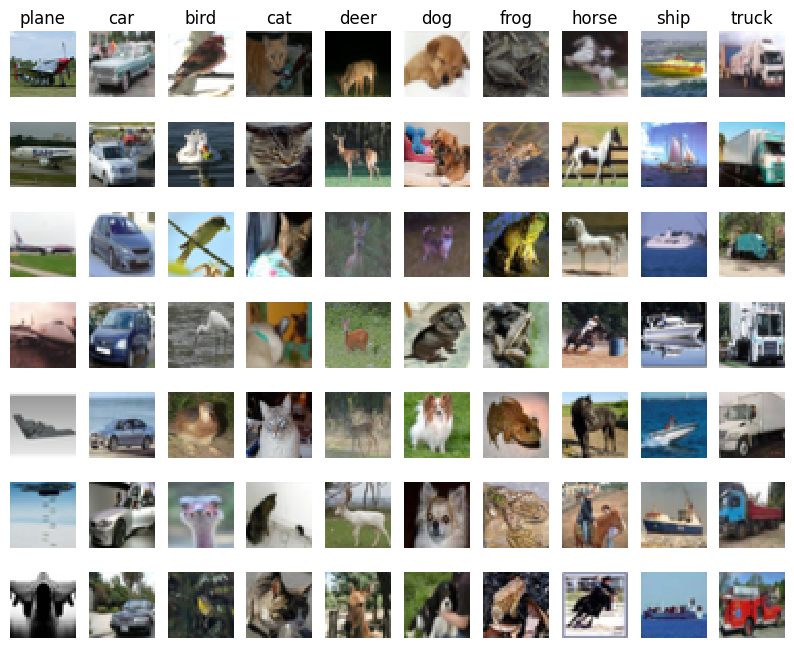

In [5]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [6]:
# Split the data into train, val, and test sets. In addition we will
# create a small development set as a subset of the training data;
# we can use this for development so our code runs faster.
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# Our validation set will be num_validation points from the original
# training set.
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Our training set will be the first num_train points from the original
# training set.
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# We will also make a development set, which is a small subset of
# the training set.
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# We use the first num_test points of the original test set as our
# test set.
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


In [7]:
# Preprocessing: reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# As a sanity check, print out the shapes of the data
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Training data shape:  (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:  (1000, 3072)
dev data shape:  (500, 3072)


[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


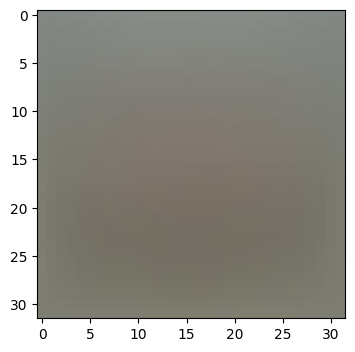

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [8]:
# Preprocessing: subtract the mean image
# first: compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) # print a few of the elements
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # visualize the mean image
plt.show()

# second: subtract the mean image from train and test data
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# third: append the bias dimension of ones (i.e. bias trick) so that our classifier
# only has to worry about optimizing a single weight matrix W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## Softmax Classifier

**Your code for this section will all be written inside** `csdc618_dscd604/classifiers/softmax.py`.

As you can see in the file `csdc618_dscd604/classifiers/softmax.py`, we have prefilled the function `softmax_loss_naive` which uses for loops to evaluate the softmax loss function.

In [9]:
# Evaluate the naive implementation of the loss we provided for you:
from csdc618_dscd604.classifiers.softmax import softmax_loss_naive
import time

# generate a random Softmax classifier weight matrix of small numbers
W = np.random.randn(3073, 10) * 0.0001

loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.379415
loss: 2.379415
sanity check: 2.302585


**Inline Question 1**

Why do we expect our loss to be close to -log(0.1)? Explain briefly.**

$\color{blue}{\textbf{Your Answer:}}$ When the weights $W$ are initialized with very small random numbers, the scores for each class (computed as $X \cdot W$) will also be very small and roughly equal for all classes. In the CIFAR-10 dataset, there are 10 classes. Therefore, the Softmax function will assign an approximately equal probability to each class, which is $1/10 = 0.1$. The Softmax loss for a single example is given by $-\log(P_{\text{true class}})$, where $P_{\text{true class}}$ is the probability assigned to the correct class. If the probability of the correct class is approximately $0.1$, then the expected initial loss will be close to $-\log(0.1)$.

---

The `grad` returned from the function the `softmax_loss_naive` is right now **all zero**. Derive and implement the gradient for the softmax loss function and implement it inline inside the function `softmax_loss_naive`. You will find it helpful to interleave your new code inside the existing function.

To check that you have correctly implemented the gradient, you can numerically estimate the gradient of the loss function and compare the numeric estimate to the gradient that you computed. We have provided code that does this for you below:

In [10]:
# Once you've implemented the gradient, recompute it with the code below
# and gradient check it with the function we provided for you

# Compute the loss and its gradient at W.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should match
# almost exactly along all dimensions.
from csdc618_dscd604.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# do the gradient check once again with regularization turned on
# you didn't forget the regularization gradient did you?
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 1.967595 analytic: 1.967595, relative error: 9.844013e-09
numerical: -2.466352 analytic: -2.466352, relative error: 1.207484e-08
numerical: -2.487088 analytic: -2.487088, relative error: 2.079264e-08
numerical: 1.459546 analytic: 1.459546, relative error: 1.765288e-08
numerical: -2.073866 analytic: -2.073866, relative error: 3.411909e-09
numerical: 1.507799 analytic: 1.507799, relative error: 4.144974e-08
numerical: -0.912382 analytic: -0.912382, relative error: 2.364902e-09
numerical: 0.534245 analytic: 0.534245, relative error: 5.798634e-08
numerical: -2.130010 analytic: -2.130010, relative error: 2.210765e-09
numerical: 2.651410 analytic: 2.651410, relative error: 1.531777e-08
numerical: 0.705152 analytic: 0.705152, relative error: 8.369523e-09
numerical: 3.709995 analytic: 3.709995, relative error: 5.047959e-09
numerical: 0.507515 analytic: 0.507514, relative error: 3.687218e-08
numerical: 4.122868 analytic: 4.122868, relative error: 2.818877e-09
numerical: 1.037576 anal

In [11]:
# Next implement the function softmax_loss_vectorized; for now only compute the loss;
# we will implement the gradient in a moment.
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from csdc618_dscd604.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, _ = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# The losses should match but your vectorized implementation should be much faster.
print('difference: %f' % (loss_naive - loss_vectorized))

Naive loss: 2.379415e+00 computed in 0.197616s
Vectorized loss: 2.379415e+00 computed in 0.056683s
difference: -0.000000


In [12]:
# Complete the implementation of softmax_loss_vectorized, and compute the gradient
# of the loss function in a vectorized way.

# The naive implementation and the vectorized implementation should match, but
# the vectorized version should still be much faster.
tic = time.time()
_, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

# The loss is a single number, so it is easy to compare the values computed
# by the two implementations. The gradient on the other hand is a matrix, so
# we use the Frobenius norm to compare them.
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.108944s
Vectorized loss and gradient: computed in 0.027692s
difference: 0.000000


### Stochastic Gradient Descent

We now have vectorized and efficient expressions for the loss, the gradient and our gradient matches the numerical gradient. We are therefore ready to do SGD to minimize the loss. Your code for this part will be written inside `csdc618_dscd604/classifiers/linear_classifier.py`.

In [13]:
# In the file linear_classifier.py, implement SGD in the function
# LinearClassifier.train() and then run it with the code below.
from csdc618_dscd604.classifiers import Softmax
softmax = Softmax()
tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 761.061293
iteration 100 / 1500: loss 279.380608
iteration 200 / 1500: loss 103.457088
iteration 300 / 1500: loss 39.256399
iteration 400 / 1500: loss 15.657257
iteration 500 / 1500: loss 7.051965
iteration 600 / 1500: loss 3.891201
iteration 700 / 1500: loss 2.722457
iteration 800 / 1500: loss 2.316417
iteration 900 / 1500: loss 2.191692
iteration 1000 / 1500: loss 2.157515
iteration 1100 / 1500: loss 2.084813
iteration 1200 / 1500: loss 2.086425
iteration 1300 / 1500: loss 2.034334
iteration 1400 / 1500: loss 2.039580
That took 12.248243s


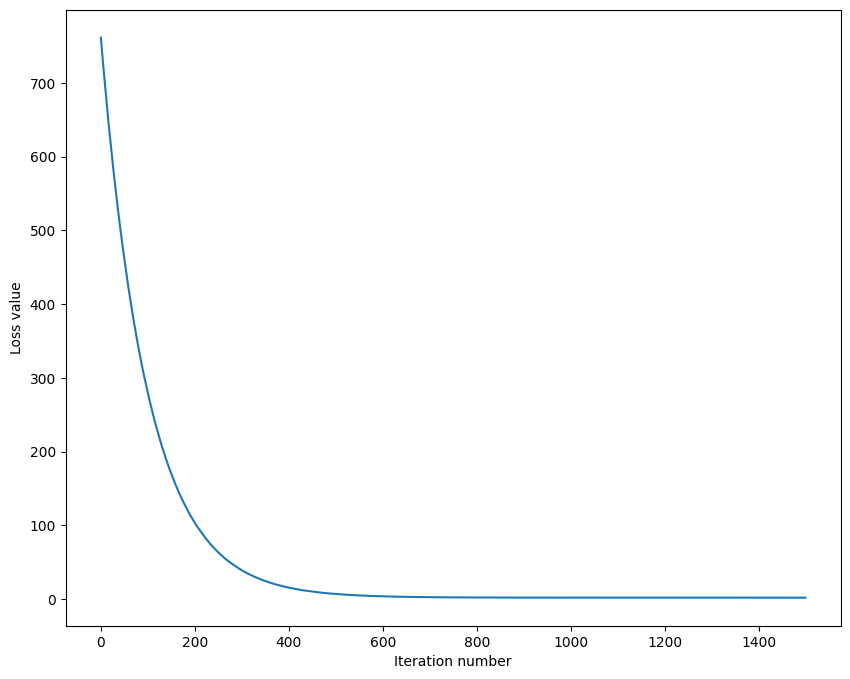

In [14]:
# A useful debugging strategy is to plot the loss as a function of
# iteration number:
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [15]:
# Write the LinearClassifier.predict function and evaluate the performance on
# both the training and validation set
# You should get validation accuracy of about 0.34 (> 0.33).
y_train_pred = softmax.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = softmax.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.331286
validation accuracy: 0.342000


In [16]:
# Save the trained model for autograder.
softmax.save("softmax.npy")

softmax.npy saved.


In [19]:
# Use the validation set to tune hyperparameters (regularization strength and
# learning rate). You should experiment with different ranges for the learning
# rates and regularization strengths; if you are careful you should be able to
# get a classification accuracy of about 0.365 (> 0.36) on the validation set.

# Note: you may see runtime/overflow warnings during hyper-parameter search.
# This may be caused by extreme values, and is not a bug.

# results is dictionary mapping tuples of the form
# (learning_rate, regularization_strength) to tuples of the form
# (training_accuracy, validation_accuracy). The accuracy is simply the fraction
# of data points that are correctly classified.
results = {}
best_val = -1   # The highest validation accuracy that we have seen so far.
best_softmax = None # The Softmax object that achieved the highest validation rate.

################################################################################
# TODO:                                                                        #
# Write code that chooses the best hyperparameters by tuning on the validation #
# set. For each combination of hyperparameters, train a Softmax on the.        #
# training set, compute its accuracy on the training and validation sets, and  #
# store these numbers in the results dictionary. In addition, store the best   #
# validation accuracy in best_val and the Softmax object that achieves this.   #
# accuracy in best_softmax.                                                    #
#                                                                              #
# Hint: You should use a small value for num_iters as you develop your         #
# validation code so that the classifiers don't take much time to train; once  #
# you are confident that your validation code works, you should rerun the      #
# code with a larger value for num_iters.                                      #
################################################################################
# Provided as a reference. You may or may not want to change these hyperparameters
learning_rates = [1e-7, 2e-7, 3e-7, 4e-7, 5e-7, 6e-7, 7e-7, 8e-7, 9e-7]
regularization_strengths = [1e4, 1.5e4, 2e4, 2.5e4, 3e4, 3.5e4, 4e4, 4.5e4, 5e4]

# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

for lr in learning_rates:
    for reg in regularization_strengths:
        softmax = Softmax()
        # Train the classifier. Use a smaller num_iters for faster tuning.
        softmax.train(X_train, y_train, learning_rate=lr, reg=reg, num_iters=1500, verbose=False)

        # Predict on the training set
        y_train_pred = softmax.predict(X_train)
        train_accuracy = np.mean(y_train == y_train_pred)

        # Predict on the validation set
        y_val_pred = softmax.predict(X_val)
        val_accuracy = np.mean(y_val == y_val_pred)

        # Store results
        results[(lr, reg)] = (train_accuracy, val_accuracy)

        # Update best validation accuracy and best Softmax object
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_softmax = softmax

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*******
################################################################################
#                             END OF YOUR CODE                                 #
################################################################################
# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.000000e-07 reg 1.000000e+04 train accuracy: 0.349714 val accuracy: 0.362000
lr 1.000000e-07 reg 1.500000e+04 train accuracy: 0.343878 val accuracy: 0.364000
lr 1.000000e-07 reg 2.000000e+04 train accuracy: 0.338490 val accuracy: 0.353000
lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.332347 val accuracy: 0.351000
lr 1.000000e-07 reg 3.000000e+04 train accuracy: 0.323286 val accuracy: 0.339000
lr 1.000000e-07 reg 3.500000e+04 train accuracy: 0.319878 val accuracy: 0.336000
lr 1.000000e-07 reg 4.000000e+04 train accuracy: 0.315592 val accuracy: 0.328000
lr 1.000000e-07 reg 4.500000e+04 train accuracy: 0.303102 val accuracy: 0.321000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.298776 val accuracy: 0.318000
lr 2.000000e-07 reg 1.000000e+04 train accuracy: 0.356469 val accuracy: 0.365000
lr 2.000000e-07 reg 1.500000e+04 train accuracy: 0.343306 val accuracy: 0.355000
lr 2.000000e-07 reg 2.000000e+04 train accuracy: 0.332265 val accuracy: 0.350000
lr 2.000000e-07 reg 2.500000

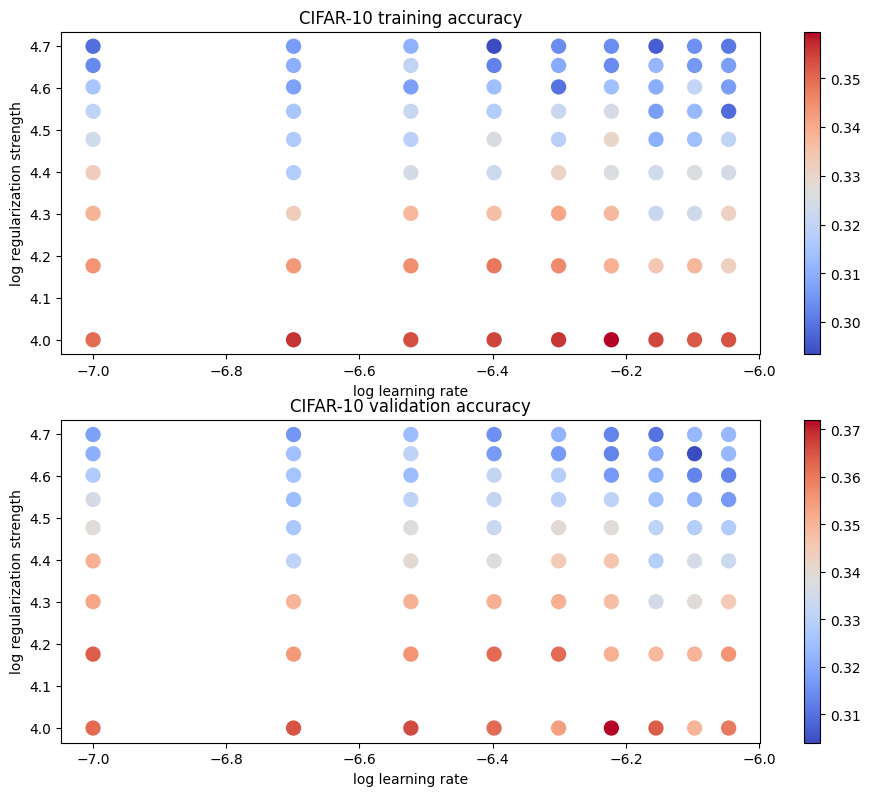

In [20]:
# Visualize the cross-validation results
import math
import pdb

# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [21]:
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('Softmax classifier on raw pixels final test set accuracy: %f' % test_accuracy)

Softmax classifier on raw pixels final test set accuracy: 0.366000


In [22]:
# Save best softmax model
best_softmax.save("best_softmax.npy")

best_softmax.npy saved.


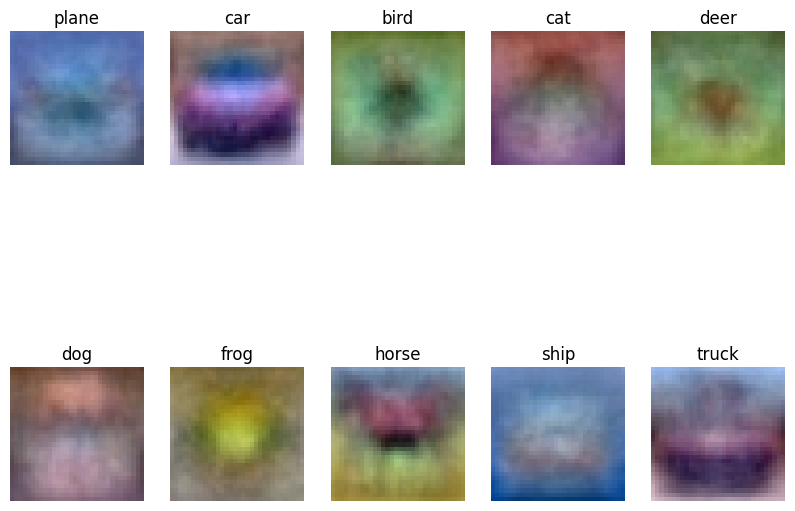

In [23]:
# Visualize the learned weights for each class.
# Depending on your choice of learning rate and regularization strength, these may
# or may not be nice to look at.
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)
w_min, w_max = np.min(w), np.max(w)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

**Inline question 3**

Describe what your visualized Softmax classifier weights look like, and offer a brief explanation for why they look the way they do.

$\color{blue}{\textbf {Your Answer:}}$ The visualized Softmax classifier weights for each class appear as blurry, averaged images that vaguely resemble the objects they are supposed to classify. For example, the 'plane' weight might show a blurry blue sky with a hint of a winged shape, and the 'car' weight often looks like a horizontal blob, potentially with reddish-brown tones (if many cars in the dataset are red or brown). Classes with more diverse appearances or similarities to other classes (like 'dog' and 'cat') might have less distinct and more ambiguous weights.

This appearance is expected for a linear classifier on image data for a few key reasons:

1.  **Linearity**: A Softmax classifier is a linear model. It learns a single weight vector (or template) for each class. When these weight vectors are reshaped back into image dimensions, they represent an "ideal" or average prototype for that class. The classifier essentially performs a dot product between the input image and these templates to determine class scores.
2.  **Averaging Effect**: Due to the high variability within each class (e.g., different breeds of dogs, cars from various angles and colors), the classifier learns an average representation across all training examples for that class. This averaging process naturally results in a blurry image rather than sharp, distinct object outlines.
3.  **Pixel-level Features**: Linear classifiers operate on raw pixel values. They learn direct correlations between pixel intensities and class labels. They lack the ability to detect complex, hierarchical features (like edges, corners, or object parts) that are common in more advanced neural networks. This limitation contributes to the 'template matching' aesthetic of the weights.
4.  **Dominant Colors/Shapes**: The colors and general shapes visible in the weights correspond to the most dominant features present in the training images for that class. For instance, if most 'ship' images feature blue water and a grey hull, the 'ship' weight will reflect these colors and a general ship-like silhouette.

In essence, each weight map can be thought of as a filter that, when convolved (or dot-producted) with an image, produces a high score if the image contains features similar to that class's average template.